In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

In [3]:
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df = df.drop_duplicates()

In [11]:
print("\nBasic Statistics")
print(df.describe())

# Mean
print("Mean Age:", df['Age'].mean())

# Median
print("Median Age:", df['Age'].median())

# Mode
print("Mode Age:", df['Age'].mode()[0])

# Standard Deviation
print("Age Standard Deviation:", df['Age'].std())



Basic Statistics
       Transaction ID                           Date         Age     Quantity  \
count     1000.000000                           1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000256    41.39200     2.514000   
min          1.000000            2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000            2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000            2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000            2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000            2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                            NaN    13.68143     1.132734   

       Price per Unit  Total Amount  
count     1000.000000   1000.000000  
mean       179.890000    456.000000  
min         25.000000     25.000000  
25%         30.000000     60.000000  
50%         50.000000    135.000000  
75%        300.000000   

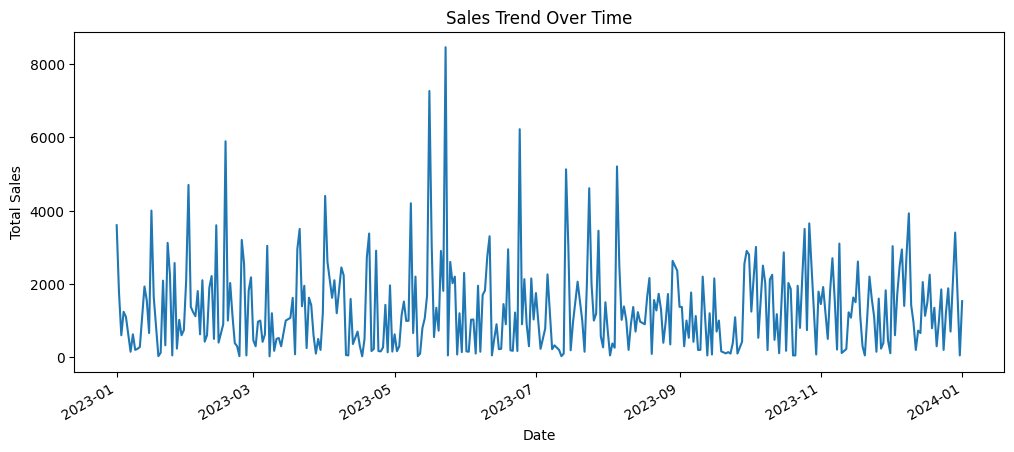

In [12]:
# Sales over time
sales_by_date = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(12,5))
sales_by_date.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

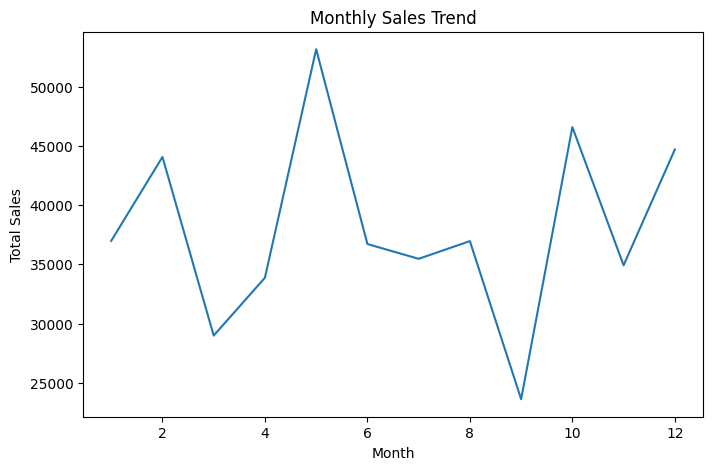

In [13]:
# Monthly sales
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

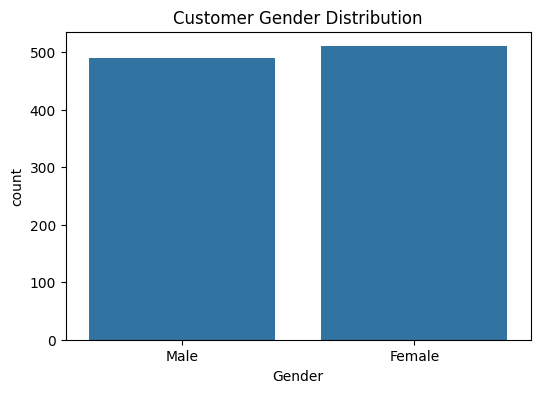

In [14]:
# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Customer Gender Distribution")
plt.show()


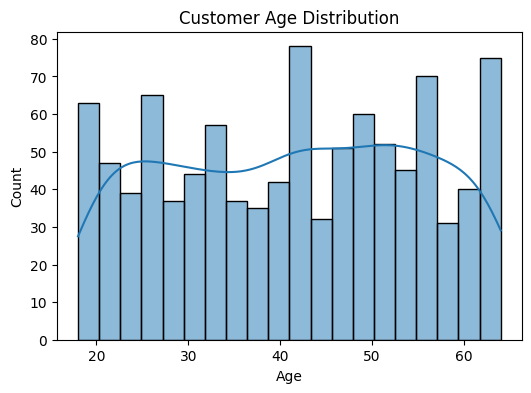

In [15]:
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Customer Age Distribution")
plt.show()


In [16]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()


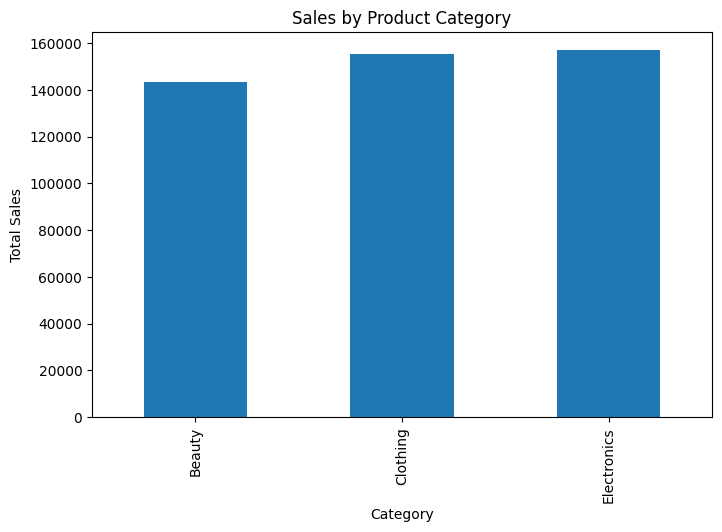

In [17]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()


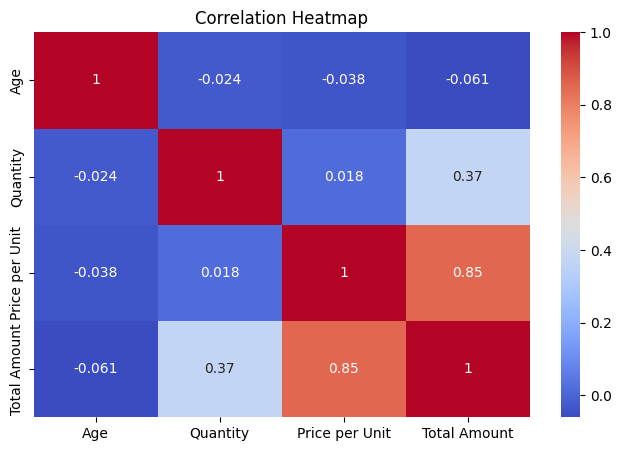

In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Age','Quantity','Price per Unit','Total Amount']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [19]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

print("Top 10 Customers by Spending")
print(top_customers)


Top 10 Customers by Spending
Customer ID
CUST487    2000
CUST476    2000
CUST773    2000
CUST503    2000
CUST093    2000
CUST089    2000
CUST946    2000
CUST157    2000
CUST155    2000
CUST420    2000
Name: Total Amount, dtype: int64


In [20]:
print("\nEDA Insights:")
print("1. Identify which product category generates the highest sales.")
print("2. Analyze which months have peak sales.")
print("3. Understand customer demographics (age & gender).")
print("4. Find high-value customers for targeted marketing.")


EDA Insights:
1. Identify which product category generates the highest sales.
2. Analyze which months have peak sales.
3. Understand customer demographics (age & gender).
4. Find high-value customers for targeted marketing.
